
# Convolution begrijpen door te kijken

In deze opdracht ga je **zien** wat een convolutionele laag doet met een afbeelding.


In pytorch werken we met tensors.
- Een tensor is een geordende verzameling getallen met een vaste vorm.
- Tensors hebben een dimensie
- Tensors hebben een shape

We importeren de benodigde libraries.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


1. Geef een voorbeeld van een 0D datastructuur p / een scalar in python code. 
Wat gebeurt er als je `print(p.shape)` doet? Waarom?

2. Geef een voorbeeld van een 1D datastructuur / vector in python code. Gebruik een gewone lijst in Python. Wat gebeurt er als je `.shape` probeert te printen? En als je er nu een numpy array van maakt?

3. Geef een voorbeeld van een 2D datastructuur / matrix in python code gebruikmakend van numpy. Print de `.shape` .

4. Als we nu meerdere matrices op elkaar stapelen en meerdere batches batches hebben gebruiken we een tensor. Je kunt een numpy matrix converteren naar een tensor (gebruik een functie uit de `tourch` library). Converteer matrix naar een tensor en print de `.shape` van de tensor. Wat valt je op?


In [ ]:
## 1. Voorbeeld van een scalar (0D)
p = torch.tensor(42.0)   # één enkel getal, geen dimensies
print("Scalar waarde:", p)
# print(p.shape)  --> geeft torch.Size([]) want er zijn GEEN dimensies
# Een scalar heeft shape [] (leeg), niet (1,) — dit is het verschil met een vector
print("Shape van scalar:", p.shape)  # torch.Size([])

## 2. Voorbeeld van een vector (1D)
v_lijst = [1, 2, 3, 4, 5]   # gewone Python lijst
# v_lijst.shape  --> AttributeError! Een gewone lijst heeft geen .shape

v_numpy = np.array(v_lijst)  # numpy array WEL
print("Shape van numpy vector:", v_numpy.shape)  # (5,)  -->  1D

## 3. Voorbeeld van een matrix (2D) met numpy
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]], dtype=np.float32)
print("Shape van matrix:", matrix.shape)   # (3, 3)

## 4. Converteer matrix naar een tensor
tensor_2d = torch.tensor(matrix)
print("Shape van tensor:", tensor_2d.shape)   # torch.Size([3, 3])
# Wat valt op? De shape is hetzelfde (3x3), maar nu is het een PyTorch tensor
# (i.p.v. numpy array). PyTorch gebruikt torch.Size i.p.v. een tuple.

Scalar waarde: tensor(42.)
Shape van scalar: torch.Size([])
Shape van numpy vector: (5,)
Shape van matrix: (3, 3)
Shape van tensor: torch.Size([3, 3])


PyTorch gebruikt 4D tensors voor afbeeldingen.
Hoewel een afbeelding dus 2D is komen er de volgende demensies bij:

**Batch (B)**

Het netwerk wil meerdere afbeeldingen tegelijk kunnen verwerken
Ook als je er maar één hebt moet je dus 1 opgeven

**Channels (C)**

Een afbeelding bestaat uit kanalen (grijs = 1, zoals bij MNIST), maar wat zijn dan bijvoorbeeld 3 kanalen denk je?


Dus zo'n 4D afbeelding moet de volgende dementies hebben (B, C, H, W)

5. Converteer nu de 2D tensor die je hierboven hebt gemaakt naar een 4D tensor. Omdat we maar 1 afbeelding en een kanaal hebben zou het dus (1, 1, Height, Width) moeten zijn.
Tip: kijk naar de functie `unsqueeze(0)`. je kunt `.shape` gebruiken om te controleren of de formaat die je eruit hebt klopt. 

In [3]:
## 5. Maak van de 2D tensor (3,3) een 4D tensor (1, 1, 3, 3)
# unsqueeze(0) voegt een dimensie toe aan het begin
tensor_4d = tensor_2d.unsqueeze(0).unsqueeze(0)   # (3,3) --> (1,3,3) --> (1,1,3,3)
print("Shape 4D tensor:", tensor_4d.shape)   # torch.Size([1, 1, 3, 3])

# Alternatief in één stap:
# tensor_4d = tensor_2d[None, None, :, :]

Shape 4D tensor: torch.Size([1, 1, 3, 3])



## Opdracht 1 — Eén convolutionele laag

We bekijken een extreem simpel neuraal netwerk:
- 1 convolutionele laag
- geen training
- alleen kijken naar de output


### Stap 1: Begrijp het netwerk
Lees onderstaande code aandachtig.


In [4]:

class SimpleConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 4, 3, padding=1)

    def forward(self, x):
        # intern gebeurt dit: self.conv.forward(x)
        return self.conv(x)



### Vragen (beantwoord zonder code uit te voeren)

**6. Hoeveel filters zitten in deze laag?**

Er zitten **4 filters** in deze laag. Dit is het tweede argument van `nn.Conv2d(1, 4, 3, padding=1)`. Het eerste getal (1) is het aantal input-kanalen, het tweede getal (4) is het aantal output-kanalen, oftewel het aantal filters.

**7. Wat is de kernel size van elk filter?**

De kernel size is **3×3**. Dit is het derde argument. Elk filter is dus een klein 3-bij-3 raster van gewichten dat over de afbeelding schuift.

**8. Waarom is `padding=1` hier logisch?**

Met een 3×3 kernel en padding=1 blijft de output **even groot als de input**. Zonder padding zou de output rondom de randen 1 pixel kleiner worden (128×128 → 126×126). Met padding=1 worden er aan elke kant nul-pixels toegevoegd zodat de output wél 128×128 blijft. Dat is handig als je de spatiale afmetingen wilt bewaren.

**9. Als de input `(1, 1, 128, 128)` is, wat is dan de vorm van de output?**

De output is **(1, 4, 128, 128)**.
- Batch blijft 1
- Kanalen: van 1 → 4 (want 4 filters)
- Hoogte en breedte blijven 128×128 dankzij padding=1



### Stap 2: Input voorbereiden

We hebben één grijswaarden-afbeelding genaamd `image`.
De plotting-code krijg je al.

10. Je maakt een lege afbeelding aan van 128 bij 128 door gebruik te maken van `image = np.zeros`.
Teken er nu met code een gevulde vierkant of een rechthoek in door bepaalde pixels op 1 te zetten. 


11. Maar er een 4D tensor van zoals we in de eerdere opdracht hebben gedaan

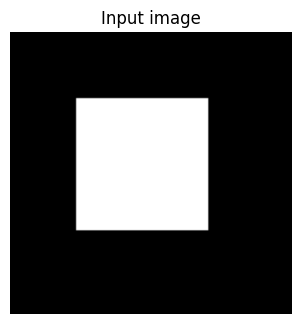

Shape van x: torch.Size([1, 1, 128, 128])


In [ ]:

# gegeven: een afbeelding met shape (H, W)
H, W = 128, 128

# maak eerst een lege afbeelding door alle pixels leeg te laten
image = np.zeros((H, W), dtype=np.float32)

## 10. Teken een gevuld vierkant (rijen 30-90, kolommen 30-90)
image[30:90, 30:90] = 1.0   # pixels op 1.0 zetten = wit

# toon je afbeelding (witte vierkant op zwarte achtergrond)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Input image")
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

# 11. Maak een tensor van de afbeelding
x = torch.tensor(image)        
x = x.unsqueeze(0).unsqueeze(0) 

# print de shape ter controle
print("Shape van x:", x.shape)  # torch.Size([1, 1, 128, 128])



### Stap 3: Forward pass en visualisatie

We laten de afbeelding door de convolutionele laag lopen
en plotten elke feature map.


Bekijk de plots goed en denk na over wat je ziet.


tensor([[[-0.2241,  0.2164,  0.2029],
         [-0.0027,  0.0966, -0.0550],
         [ 0.1710, -0.2573, -0.0801]]], grad_fn=<SelectBackward0>)


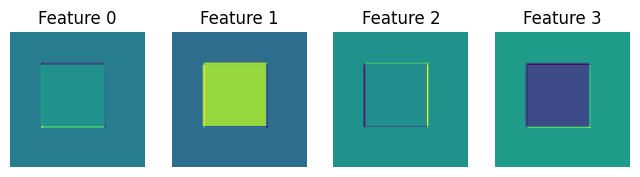

In [6]:

model = SimpleConv()

# toon hier een random kernel
print(model.conv.weight[0])


# model(x) roept automatisch model.forward(x) aan
# detach() gebruik je als je een tensor alleen wilt bekijken en niet wilt trainen.
# we kiezen [0] de demensie omdat dat de batch is (en er is maar 1)
feat = model(x).detach().numpy()[0]

plt.figure(figsize=(8, 3))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f"Feature {i}")
    plt.imshow(feat[i], cmap="viridis")
    plt.axis("off")
plt.show()



### Vragen

**12. We kunnen de 0 in `model.conv.weight[0]` ook door andere getallen vervangen. Waarom?**

De `0` is de **index** van een filter. We hebben 4 filters (indices 0 t/m 3). Door `weight[1]`, `weight[2]` of `weight[3]` te gebruiken kun je de kernel van een ander filter bekijken. Elk filter heeft zijn eigen willekeurig geïnitialiseerde gewichten en leert daardoor iets anders te detecteren.

**13. Waarom krijgen we vier afbeeldingen te zien?**

Omdat de convolutionele laag **4 filters** heeft. Elke filter schuift over de volledige input-afbeelding en produceert zijn eigen output-kanaal (feature map). Vier filters → vier feature maps.

**14. Lijken deze feature maps op de originele afbeelding? Waarom wel / niet?**

Deels wel, deels niet. De **globale structuur** (het vierkant) is nog herkenbaar, maar elke feature map ziet er anders uit. Dat komt doordat elke filter andere willekeurige gewichten heeft en daardoor op andere patronen reageert — de ene filter reageert sterk op bepaalde randen, de andere op andere richtingen of texturen. De convolutie benadrukt of onderdrukt bepaalde kenmerken.

**15. Rund het laatste stukje nog een keer. Veranderen de afbeeldingen? Waarom?**

**Ja**, de feature maps veranderen bij elke run. Dat komt omdat `SimpleConv()` elke keer opnieuw aangemaakt wordt, en PyTorch initialiseert de gewichten van `nn.Conv2d` **willekeurig** (standaard met Kaiming-initialisatie). Nieuwe willekeurige gewichten → andere filterresponses → andere feature maps. Als je de weights vóór de forward pass zou opslaan en hergebruiken, zouden de outputs identiek zijn.
